Проект: вариант 1
    
Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:

    
1) В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.

2) Помимо этого, в компании провели A/B тестирование наборов акционных предложений. На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять правильное решение.

3) Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.

1.Retention – один из самых важных показателей в компании. Посчитаем retention игроков (по дням от даты регистрации игрока). 

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
#путь до папки
reg_path = '/shared/problem1-reg_data.csv'
auth_path = '/shared/problem1-auth_data.csv'

In [15]:
#выгружаем данные
reg_data = pd.read_csv(reg_path, sep=';')
auth_data = pd.read_csv(auth_path, sep=';')

In [16]:
#проверяю что выгрузила
reg_data.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [17]:
#проверяю что выгрузила
auth_data.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [18]:
#посмотрим общую информацию о данных регистрации
reg_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB


In [19]:
#посмотрим общую информацию о данных авторизации
auth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB


In [20]:
#тестим на наличие пропусков
reg_data.isna().sum()
auth_data.isna().sum()

auth_ts    0
uid        0
dtype: int64

In [21]:
#смотрим наличие дубликатов
reg_data.duplicated().sum()
auth_data.duplicated().sum()

0

Оценим также идентификаторы на уникальность (сопоставим количество строк в каждой таблице с количеством уникальных uid)

In [22]:
reg_data['uid'].nunique()
auth_data['uid'].nunique()

1000000

Т.о., наши данные не содержат пропусков, не содержат дубликатов, а количество уникальных uid совпадаем с количеством строк. Т.о., можно сделать вывод, что абсолютно каждый зарегистрированный пользователь зашёл в игру как минимум один раз (в день регистрации или позже).

In [23]:
def calculate_retention(reg_path, auth_path):
    #выгружаем данные
    reg_data = pd.read_csv(reg_path, sep=';')
    auth_data = pd.read_csv(auth_path, sep=';')
    
    #переводим колонку reg_ts в формат даты и перезаписываем ее в reg_data (unit='s', т.к.данные в unix timestamp записано в секундах)
    reg_data['reg_ts'] = pd.to_datetime(reg_data['reg_ts'], unit='s')
    auth_data['auth_ts'] = pd.to_datetime(auth_data['auth_ts'], unit='s')
    
    #приводим к дате без точного времени через dt.normalize() до ГГГГ-ММ-ДД, т.к. колонки auth_ts и reg_ts сейчас представлены в формате целых чисел (int64).
    reg_data['reg_date'] = reg_data['reg_ts'].dt.normalize()
    auth_data['auth_date'] = auth_data['auth_ts'].dt.normalize()
    
    #ставим ограничение по дате регистрации (т.к. иначе "умирает" ядро) и аналогично по дате авторизации
    reg_data = reg_data[(reg_data['reg_date'] >= '2020-09-01') & (reg_data['reg_date'] <= '2020-09-21')]
    auth_data = auth_data[auth_data['uid'].isin(reg_data['uid'])]

    #объединяем таблицы по пользователям в одну общую структуру, чтобы для каждой записи об авторизации была запись о регистрации пользователя (объединяем по уникальному идентификатору)
    reg_auth_table = reg_data.merge(auth_data, on='uid', how='inner')
    
    #ищем разницу между днем, когда пользователь заходил и днем регистрации, находим разницу и переводим её в целое число дней
    reg_auth_table['days_since_reg_date'] = (reg_auth_table['auth_date'] - reg_auth_table['reg_date']).dt.days
    
    #группируем и агрегируем (по уникальным пользователям)
    cohort_data = reg_auth_table.groupby(['reg_date', 'days_since_reg_date'], as_index=False).agg({'uid': 'nunique'})
    
    #переименовываем колонку (т.к. в uid - уникальные идентификаторы, а после nunique - количество человек)
    cohort_data = cohort_data.rename(columns={'uid': 'active_users_count'})
    
    #переводим колонку с датой в текст 
    cohort_data['reg_date'] = cohort_data['reg_date'].dt.strftime('%Y-%m-%d')
    
    #строим таблицу pivot
    retention_pivot = cohort_data.pivot(index='reg_date', columns='days_since_reg_date', values='active_users_count')
    
    #0 столбец - исходное количество зарегистрированных в этот день пользователей. 1,2 и тд - показывает кто вернулся в какой день
    #Т.к. в таблице много пропусков (NaN), то определим временной промежуток для дальнейшего расчета retention
    
    #временные границы исследования
    min_date = reg_data['reg_date'].min()
    max_date = auth_data['auth_date'].max()
    print(f"Анализируем данные за период с {min_date} по {max_date}.\n")

    #расчитываем размеры когорт
    cohort_size = retention_pivot.iloc[:, 0]
    
    #считаем коэффициент удержания
    retention_matrix = retention_pivot.divide(cohort_size, axis=0) 
    
    #считаем Retention Rate в процентах
    retention_rate = (retention_matrix * 100).round(2)
    
    return retention_rate

Анализируем данные за период с 2020-09-01 00:00:00 по 2020-09-23 00:00:00.



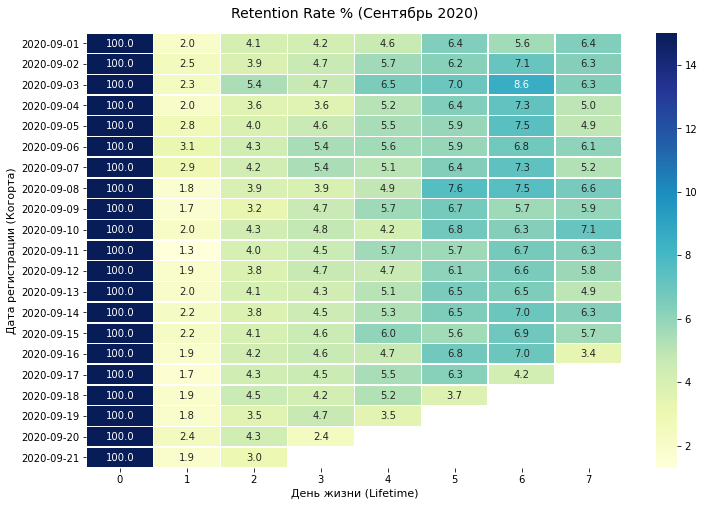

In [24]:
#визуализируем 

#путь до папки
reg_path = '/shared/problem1-reg_data.csv'
auth_path = '/shared/problem1-auth_data.csv'

#Вызываем функцию
retention_rate = calculate_retention(reg_path, auth_path)

#делаем маленький срез по датам и дням за сентябрь 2020 года
retention_part = retention_rate.loc['2020-09-01':'2020-09-21', 0:7]

#настраиваем размер и рисуем тепловую карту
plt.figure(figsize=(12, 8))

sns.heatmap(
    retention_part,       
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',      
    linewidths=0.5,
    vmax=15
)

plt.title('Retention Rate % (Сентябрь 2020)', fontsize=14, pad=15)
plt.ylabel('Дата регистрации (Когорта)', fontsize=11)
plt.xlabel('День жизни (Lifetime)', fontsize=11)

plt.show()

Выводы:
1. Для оптимизации работы данные были отфильтрованы с 2020 года, т.к.в памяти содержится инфомация за 20 лет, что влияет на работу кода (ядро "умирает")
2. Для анализа был выбран самый свежий период - первые 3 недели сентября 2020 г, т.к. более ранние данные менее актуальны. Для анализа взяты 3 недели, чтобы у каждой когорты на карте были точно 7 дней.
3. Анализ тепловой карты: 
В нулевой день retention равен 100% (день регистрации пользователей).
Начиная с 1 дня выявляется большой отток на старте (в среднем в первый день возврат около 2,1 игроков), при этом с 4 по 7 деннь наблюдается рост метрики (в диапазоне от 3,4 до 8,6 игроков) 